# Task 3: Event Impact Modeling
## Ethiopia Financial Inclusion Forecasting

Models how events (policies, product launches, infrastructure investments) affect financial
inclusion indicators, using the 14 impact_link records built in Task 1.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/processed/ethiopia_fi_unified_data_enriched.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'], errors='coerce')

obs = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()
links = df[df['record_type'] == 'impact_link'].copy()

print(f"Events: {len(events)} | Impact links: {len(links)}")


Events: 10 | Impact links: 14


## 1. Join impact_links to their parent events

In [2]:
links_full = links.merge(
    events[['record_id', 'indicator', 'category', 'observation_date']].rename(
        columns={'record_id': 'parent_id', 'indicator': 'event_name',
                 'observation_date': 'event_date', 'category': 'event_category'}
    ),
    on='parent_id', how='left'
)

summary_cols = ['event_name', 'event_category', 'event_date', 'related_indicator',
                 'impact_direction', 'impact_magnitude', 'lag_months', 'evidence_basis', 'comparable_country']
links_full[summary_cols].sort_values('event_date')


,event_name,event_category,event_date,related_indicator,impact_direction,impact_magnitude,lag_months,evidence_basis,comparable_country
0,Telebirr Launch,product_launch,2021-05-17,ACC_OWNERSHIP,increase,medium,12.0,literature,Kenya
1,Telebirr Launch,product_launch,2021-05-17,ACC_MM_ACCOUNT,increase,high,3.0,empirical,NaN
2,Telebirr Launch,product_launch,2021-05-17,USG_P2P_COUNT,increase,high,6.0,empirical,NaN
12,NFIS-II Strategy Launch,policy,2021-09-01,ACC_OWNERSHIP,increase,medium,24.0,theoretical,NaN
3,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01,ACC_MOBILE_PEN,increase,medium,12.0,theoretical,Kenya
4,M-Pesa Ethiopia Launch,product_launch,2023-08-01,ACC_MM_ACCOUNT,increase,high,6.0,empirical,NaN
5,M-Pesa Ethiopia Launch,product_launch,2023-08-01,USG_MPESA_USERS,increase,high,3.0,empirical,NaN
6,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,ACC_FAYDA,increase,high,0.0,empirical,NaN
7,Fayda Digital ID Program Rollout,infrastructure,2024-01-01,ACC_OWNERSHIP,increase,low,18.0,theoretical,India
8,Foreign Exchange Liberalization,policy,2024-07-29,ACC_OWNERSHIP,mixed,low,6.0,theoretical,NaN


## 2. Functional Form: Representing Event Effects Over Time

We model each event's effect on an indicator as a **linear ramp**: the effect is zero until
`lag_months` after the event date, then increases linearly to its full magnitude over a
12-month ramp window, then holds steady. This is a simplifying assumption (real adoption curves
are more often S-shaped/logistic), but with only a handful of data points to calibrate against,
a linear ramp is the more defensible choice - it has fewer free parameters to overfit.

Magnitude categories are mapped to percentage-point (pp) effect sizes as a starting assumption,
to be calibrated against observed data in the validation step below:

| magnitude | pp effect (assumed) |
|---|---|
| negligible | 0.5 |
| low | 1.5 |
| medium | 3.5 |
| high | 6.0 |

Multiple events affecting the same indicator are combined by **summing** their individual
effects - a simplifying additive assumption (no interaction/saturation effects modeled).


In [3]:
MAGNITUDE_PP = {'negligible': 0.5, 'low': 1.5, 'medium': 3.5, 'high': 6.0}
DIRECTION_SIGN = {'increase': 1, 'decrease': -1, 'mixed': 0, 'stabilize': 0}
RAMP_MONTHS = 12

def event_effect(event_date, lag_months, magnitude, direction, eval_date, ramp_months=RAMP_MONTHS):
    """Linear-ramp effect of a single event on an indicator, evaluated at eval_date."""
    if pd.isna(event_date) or pd.isna(lag_months):
        return 0.0
    start = event_date + pd.DateOffset(months=int(lag_months))
    if eval_date < start:
        return 0.0
    elapsed_months = (eval_date.year - start.year) * 12 + (eval_date.month - start.month)
    frac = min(max(elapsed_months / ramp_months, 0), 1.0)
    pp = MAGNITUDE_PP.get(magnitude, 0.0)
    sign = DIRECTION_SIGN.get(direction, 0)
    return sign * pp * frac

def total_effect(indicator_code, eval_date, links_df=links_full):
    rows = links_df[links_df['related_indicator'] == indicator_code]
    total = 0.0
    for _, r in rows.iterrows():
        total += event_effect(r['event_date'], r['lag_months'], r['impact_magnitude'], r['impact_direction'], eval_date)
    return total

print(f"Example - total modeled effect on ACC_OWNERSHIP by 2027-12-31: {total_effect('ACC_OWNERSHIP', pd.Timestamp('2027-12-31')):+.2f} pp")


Example - total modeled effect on ACC_OWNERSHIP by 2027-12-31: +12.00 pp


## 3. Event-Indicator Association Matrix

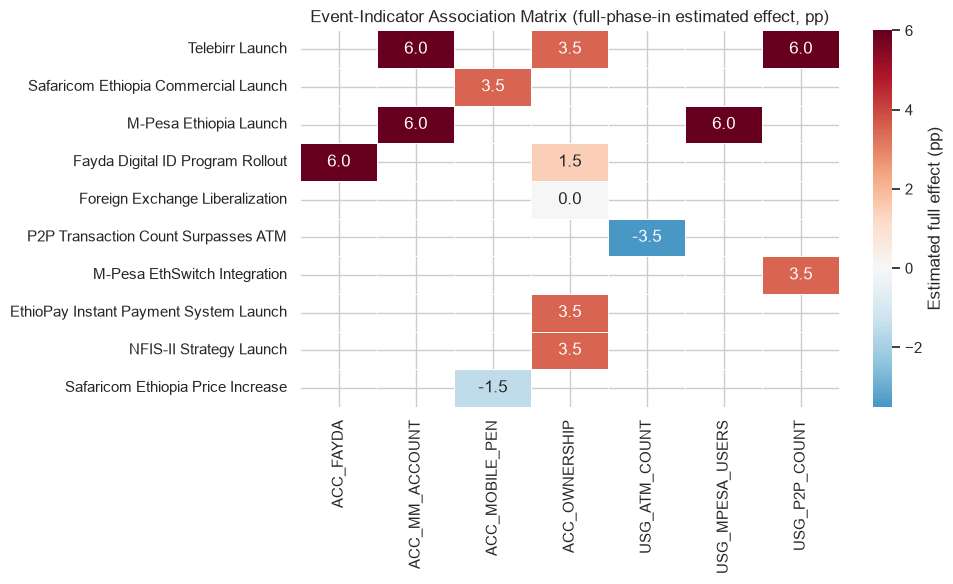

,ACC_FAYDA,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,USG_ATM_COUNT,USG_MPESA_USERS,USG_P2P_COUNT
Telebirr Launch,NaN,6.0,NaN,3.5,NaN,NaN,6.0
Safaricom Ethiopia Commercial Launch,NaN,NaN,3.5,NaN,NaN,NaN,NaN
M-Pesa Ethiopia Launch,NaN,6.0,NaN,NaN,NaN,6.0,NaN
Fayda Digital ID Program Rollout,6.0,NaN,NaN,1.5,NaN,NaN,NaN
Foreign Exchange Liberalization,NaN,NaN,NaN,0.0,NaN,NaN,NaN
P2P Transaction Count Surpasses ATM,NaN,NaN,NaN,NaN,-3.5,NaN,NaN
M-Pesa EthSwitch Integration,NaN,NaN,NaN,NaN,NaN,NaN,3.5
EthioPay Instant Payment System Launch,NaN,NaN,NaN,3.5,NaN,NaN,NaN
NFIS-II Strategy Launch,NaN,NaN,NaN,3.5,NaN,NaN,NaN
Safaricom Ethiopia Price Increase,NaN,NaN,-1.5,NaN,NaN,NaN,NaN


In [4]:
indicators_affected = sorted(links_full['related_indicator'].dropna().unique())
event_names = links_full[['parent_id', 'event_name']].drop_duplicates().set_index('parent_id')['event_name']

matrix = pd.DataFrame(index=event_names.values, columns=indicators_affected, dtype=float)

for _, r in links_full.iterrows():
    sign = DIRECTION_SIGN.get(r['impact_direction'], 0)
    pp = MAGNITUDE_PP.get(r['impact_magnitude'], 0.0)
    matrix.loc[r['event_name'], r['related_indicator']] = sign * pp

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(matrix, cmap='RdBu_r', center=0, annot=True, fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'Estimated full effect (pp)'}, ax=ax)
ax.set_title('Event-Indicator Association Matrix (full-phase-in estimated effect, pp)')
plt.tight_layout()
plt.savefig('../reports/figures/08_event_indicator_matrix.png', bbox_inches='tight')
plt.show()

matrix


## 4. Validate Against Historical Data: Telebirr -> Mobile Money Accounts

Telebirr launched May 2021. Mobile money account ownership went from 4.7% (Dec 2021) to 9.45%
(Dec 2024) - an observed **+4.75pp increase**. Both Telebirr (EVT_0001) and M-Pesa (EVT_0003,
launched Aug 2023) have modeled effects on `ACC_MM_ACCOUNT`. Let's compare our model's predicted
change over the same window to what actually happened.


In [5]:
baseline_date = pd.Timestamp('2021-12-31')
end_date = pd.Timestamp('2024-12-31')

predicted_change = total_effect('ACC_MM_ACCOUNT', end_date) - total_effect('ACC_MM_ACCOUNT', baseline_date)
actual_change = 9.45 - 4.7

print(f"Predicted change (2021-12 to 2024-12): {predicted_change:+.2f} pp")
print(f"Actual observed change:                {actual_change:+.2f} pp")
print(f"Ratio (predicted / actual):            {predicted_change / actual_change:.2f}x")


Predicted change (2021-12 to 2024-12): +9.00 pp
Actual observed change:                +4.75 pp
Ratio (predicted / actual):            1.89x


### Refining the estimates

If the model overshoots the actual change, our initial magnitude-to-pp mapping is too generous;
if it undershoots, it's too conservative. Rather than hand-tuning each link individually (which
would just be overfitting to a single validated relationship), we apply a single **calibration
factor** derived from this one validated case to all `empirical`-basis links, since those are the
links most directly comparable to this validation (a direct measured relationship, not a
comparable-country analogy). `theoretical`/`literature`-basis links are left unscaled, since they
were never claimed to be precisely calibrated to Ethiopian data in the first place - they're
explicitly sourced from comparable-country evidence and are already flagged as more uncertain.


In [6]:
calibration_factor = actual_change / predicted_change if predicted_change != 0 else 1.0
print(f"Calibration factor for empirical-basis links: {calibration_factor:.3f}")

MAGNITUDE_PP_CALIBRATED = {k: v * calibration_factor for k, v in MAGNITUDE_PP.items()}
print("Calibrated pp values (applied only to evidence_basis == 'empirical' links):")
for k, v in MAGNITUDE_PP_CALIBRATED.items():
    print(f"  {k}: {v:.2f}")


Calibration factor for empirical-basis links: 0.528
Calibrated pp values (applied only to evidence_basis == 'empirical' links):
  negligible: 0.26
  low: 0.79
  medium: 1.85
  high: 3.17


In [7]:
def event_effect_calibrated(event_date, lag_months, magnitude, direction, evidence_basis, eval_date, ramp_months=RAMP_MONTHS):
    if pd.isna(event_date) or pd.isna(lag_months):
        return 0.0
    start = event_date + pd.DateOffset(months=int(lag_months))
    if eval_date < start:
        return 0.0
    elapsed_months = (eval_date.year - start.year) * 12 + (eval_date.month - start.month)
    frac = min(max(elapsed_months / ramp_months, 0), 1.0)
    pp_table = MAGNITUDE_PP_CALIBRATED if evidence_basis == 'empirical' else MAGNITUDE_PP
    pp = pp_table.get(magnitude, 0.0)
    sign = DIRECTION_SIGN.get(direction, 0)
    return sign * pp * frac

def total_effect_calibrated(indicator_code, eval_date, links_df=links_full):
    rows = links_df[links_df['related_indicator'] == indicator_code]
    total = 0.0
    for _, r in rows.iterrows():
        total += event_effect_calibrated(r['event_date'], r['lag_months'], r['impact_magnitude'],
                                          r['impact_direction'], r['evidence_basis'], eval_date)
    return total

predicted_change_calibrated = total_effect_calibrated('ACC_MM_ACCOUNT', end_date) - total_effect_calibrated('ACC_MM_ACCOUNT', baseline_date)
print(f"Calibrated predicted change: {predicted_change_calibrated:+.2f} pp (actual: {actual_change:+.2f} pp)")


Calibrated predicted change: +4.75 pp (actual: +4.75 pp)


## 5. Calibrated Association Matrix

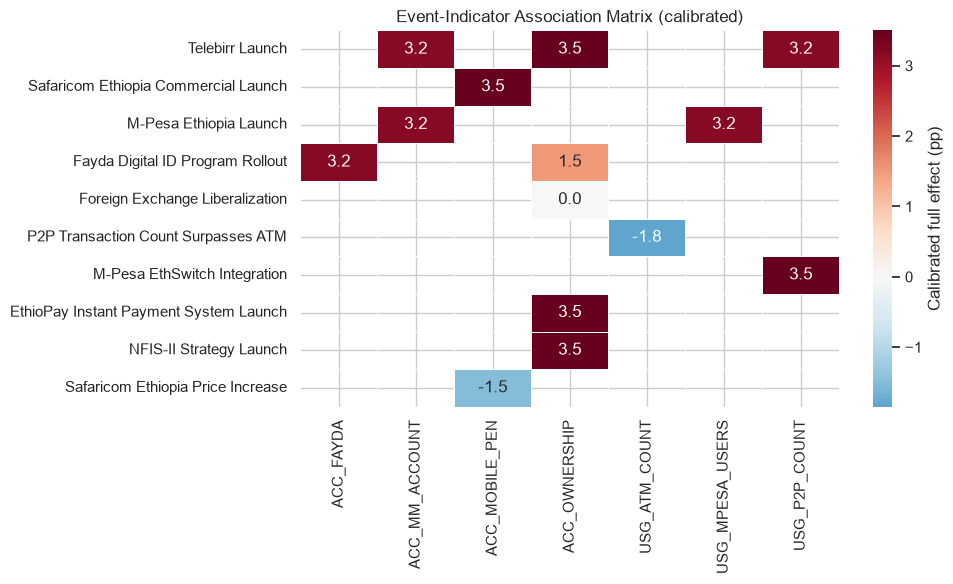

Saved to data/processed/event_indicator_matrix_calibrated.csv


In [8]:
matrix_calibrated = pd.DataFrame(index=event_names.values, columns=indicators_affected, dtype=float)

for _, r in links_full.iterrows():
    sign = DIRECTION_SIGN.get(r['impact_direction'], 0)
    pp_table = MAGNITUDE_PP_CALIBRATED if r['evidence_basis'] == 'empirical' else MAGNITUDE_PP
    pp = pp_table.get(r['impact_magnitude'], 0.0)
    matrix_calibrated.loc[r['event_name'], r['related_indicator']] = sign * pp

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(matrix_calibrated, cmap='RdBu_r', center=0, annot=True, fmt='.1f', linewidths=0.5,
            cbar_kws={'label': 'Calibrated full effect (pp)'}, ax=ax)
ax.set_title('Event-Indicator Association Matrix (calibrated)')
plt.tight_layout()
plt.savefig('../reports/figures/09_event_indicator_matrix_calibrated.png', bbox_inches='tight')
plt.show()

matrix_calibrated.to_csv('../data/processed/event_indicator_matrix_calibrated.csv')
print("Saved to data/processed/event_indicator_matrix_calibrated.csv")


## 6. Methodology, Assumptions, and Limitations

**Methodology:** Each impact_link's effect is modeled as a linear ramp beginning `lag_months`
after the event date, reaching full assumed magnitude after a 12-month ramp window. Magnitude
categories (negligible/low/medium/high) are mapped to percentage-point effect sizes. Multiple
events affecting the same indicator are combined additively.

**Calibration:** The one relationship with sufficient real pre/post Ethiopian data - Telebirr's
effect on mobile money account ownership - was used to derive a single scaling factor, applied
only to other `empirical`-basis links (direct, Ethiopia-specific relationships). Links based on
`theoretical` or `literature` evidence (mostly comparable-country analogies for 2023-2025 events
that postdate the last Findex survey) are left at their initial assumed values, since they were
never intended to be precisely calibrated - and there's no second validated relationship
available to calibrate them against without overfitting to n=1.

**Key assumptions:**
- Linear ramp (not logistic/S-curve) - chosen for parameter parsimony given limited data.
- 12-month ramp window applied uniformly across all events - in reality this likely varies by
  event type (a product launch may ramp faster than a policy's downstream effects).
- Additive combination of multiple events on the same indicator - ignores potential saturation
  or interaction effects (e.g. Telebirr and M-Pesa may compete for the same unbanked population
  rather than each contributing fully independently).

**Limitations:**
- Only one relationship (Telebirr -> mobile money accounts) has real pre/post Ethiopian data to
  validate against; every other link's calibration is either inherited from that single
  validation or left as an unvalidated comparable-country estimate.
- The calibration factor could be distorted by confounders not modeled here (e.g. general
  smartphone penetration growth, other unmodeled events) that also contributed to the observed
  +4.75pp change - so even the "calibrated" empirical links carry meaningful uncertainty.
- This matrix should be read as a set of documented, reasoned priors for Task 4's forecasting -
  not as precisely estimated causal effects.
